# ULB/Worldline Credit-Card Fraud: EDA and Predictive Modelling

**Dataset role:** real, anonymized public benchmark.

This notebook implements a thesis-safe workflow:

- integrity checks are performed before modelling;
- exact duplicates are handled before splitting;
- the test set is never balanced, augmented, or used for feature selection;
- target-informed EDA uses training data only;
- model selection and threshold selection use validation data only;
- the selected model is evaluated once on the untouched test set;
- PR-AUC is the primary selection metric.



In [1]:
from __future__ import annotations

from pathlib import Path
import hashlib
import json
import platform
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import imblearn
from IPython import get_ipython
from IPython.display import display

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbalancedPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


SEED = 42
TEST_SIZE = 0.20
VALIDATION_SIZE_WITHIN_DEVELOPMENT = 0.20
PRIMARY_METRIC = "average_precision"
FBETA = 2.0

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.5f}")


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        ulb_data = candidate / "datasets" / "ULB_creditCard.csv"
        if ulb_data.exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Run from thesis_code or one of its subdirectories.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / "datasets" / "ULB_creditCard.csv"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "ulb"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))
from src.evaluation import (  # noqa: E402
    evaluation_rows,
    plot_confusion_summary,
    plot_diagnostics,
    plot_threshold_tradeoff,
    plot_validation_comparison,
    positive_class_scores,
    save_json,
    select_fbeta_threshold,
)
from src.evidence import build_alert_records, write_jsonl  # noqa: E402

print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit_learn": sklearn.__version__,
    "imbalanced_learn": imblearn.__version__,
    "project_root": str(PROJECT_ROOT),
})



{'python': '3.13.5', 'pandas': '2.3.1', 'numpy': '2.3.2', 'scikit_learn': '1.6.1', 'imbalanced_learn': '0.13.0', 'project_root': '<REPOSITORY_ROOT>'}


## 1. Provenance, integrity, and dataset card

Whole-dataset access in this section is restricted to schema and integrity checks.
No modelling choice is made from test-label patterns.



In [2]:
data_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
raw = pd.read_csv(DATA_PATH)

expected_columns = ["Time", *[f"V{i}" for i in range(1, 29)], "Amount", "Class"]
assert raw.columns.tolist() == expected_columns, "Unexpected ULB schema."
assert raw.shape[1] == 31
assert set(raw["Class"].unique()) == {0, 1}
assert raw.isna().sum().sum() == 0
assert np.isfinite(raw.select_dtypes(include="number")).all().all()

dataset_card = pd.Series({
    "source": "ULB/Worldline credit-card fraud benchmark",
    "rows": len(raw),
    "predictors": raw.shape[1] - 1,
    "legitimate": int((raw["Class"] == 0).sum()),
    "fraud": int((raw["Class"] == 1).sum()),
    "fraud_rate_percent": 100 * raw["Class"].mean(),
    "missing_cells": int(raw.isna().sum().sum()),
    "redundant_exact_duplicates": int(raw.duplicated().sum()),
    "sha256": data_hash,
})
dataset_card.to_frame("value")



,value
source,ULB/Worldline credit-card fraud benchmark
rows,284807
predictors,30
legitimate,284315
fraud,492
fraud_rate_percent,0.17275
missing_cells,0
redundant_exact_duplicates,1081
sha256,76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d...


In [3]:
raw.sample(5, random_state=SEED)



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43428,"41,505.00000",-16.52651,8.58497,-18.64985,9.50559,-13.79382,-2.83240,-16.70169,7.51734,-8.50706,-14.11018,5.29924,-10.83401,1.67112,-9.37386,0.36081,-9.89925,-19.23629,-8.39855,3.10174,-1.51492,1.19074,-1.12767,-2.35858,0.67346,-1.41370,-0.46276,-2.01858,-1.04280,364.19000,1
49906,"44,261.00000",0.33981,-2.74375,-0.13407,-1.38573,-1.45141,1.01589,-0.52438,0.22406,0.89975,-0.56501,-0.08767,0.97943,0.07688,-0.21788,-0.13683,-2.14289,0.12696,1.75266,0.43255,0.50604,-0.21344,-0.94253,-0.52682,-1.15699,0.31121,-0.74665,0.04100,0.10204,520.12000,0
29474,"35,484.00000",1.39959,-0.59070,0.16862,-1.02995,-0.53981,0.04044,-0.71257,0.00230,-0.97175,0.75680,0.54383,0.11245,1.07538,-0.24577,0.18048,1.76986,-0.53317,-0.53330,1.19225,0.21288,0.10240,0.16827,-0.16664,-0.81025,0.50508,-0.23234,0.01141,0.00463,31.00000,0
276481,"167,123.00000",-0.43207,1.64790,-1.66936,-0.34950,0.78578,-0.63065,0.27699,0.58602,-0.48472,-1.37665,-1.32834,0.22362,1.13263,-0.55088,0.61657,0.49797,0.50220,0.98134,0.10126,-0.24463,0.35893,0.87366,-0.17864,-0.01717,-0.20739,-0.15776,-0.23739,0.00193,1.50000,0
278846,"168,473.00000",2.01416,-0.13739,-1.01584,0.32727,-0.18218,-0.95657,0.04324,-0.16075,0.36324,0.25945,0.94216,0.85004,-0.61617,0.59263,-0.60385,0.09108,-0.47187,-0.33382,0.40471,-0.25529,-0.23864,-0.61640,0.34704,0.06156,-0.36020,0.17473,-0.07804,-0.07057,0.89000,0


## 2. Class imbalance and integrity-only EDA



,count,percent
Class,,
Legitimate,284315,99.82725
Fraud,492,0.17275


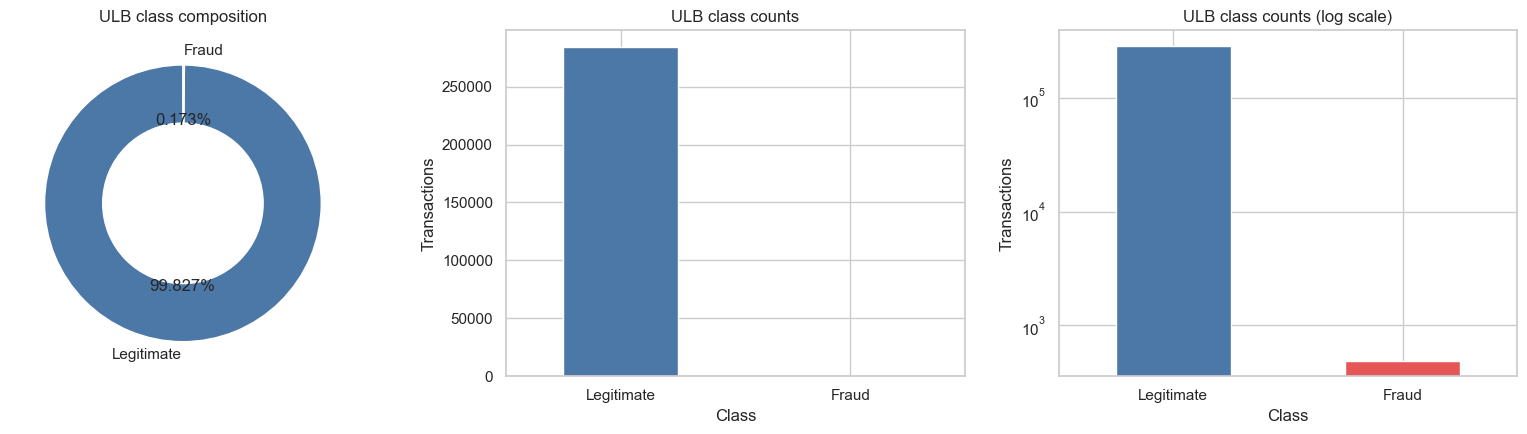

In [4]:
class_summary = (
    raw["Class"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Legitimate", 1: "Fraud"})
    .to_frame("count")
)
class_summary["percent"] = 100 * class_summary["count"] / len(raw)
display(class_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].pie(
    class_summary["count"],
    labels=class_summary.index,
    colors=["#4C78A8", "#E45756"],
    autopct=lambda value: f"{value:.3f}%",
    startangle=90,
    wedgeprops={"width": 0.42, "edgecolor": "white"},
)
axes[0].set_title("ULB class composition")
class_summary["count"].plot.bar(ax=axes[1], color=["#4C78A8", "#E45756"])
axes[1].set(title="ULB class counts", xlabel="Class", ylabel="Transactions")
class_summary["count"].plot.bar(ax=axes[2], logy=True, color=["#4C78A8", "#E45756"])
axes[2].set(title="ULB class counts (log scale)", xlabel="Class", ylabel="Transactions")
for axis in axes[1:]:
    axis.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()



In [5]:
duplicate_rows = raw[raw.duplicated(keep=False)].copy()
duplicate_audit = pd.Series({
    "rows_in_duplicate_groups": len(duplicate_rows),
    "redundant_rows": int(raw.duplicated().sum()),
    "fraud_rows_in_duplicate_groups": int(duplicate_rows["Class"].sum()),
    "redundant_fraud_rows": int(raw.loc[raw.duplicated(), "Class"].sum()),
})
duplicate_audit.to_frame("value")



,value
rows_in_duplicate_groups,1854
redundant_rows,1081
fraud_rows_in_duplicate_groups,32
redundant_fraud_rows,19


## 3. Lock the modelling partitions

The primary analysis retains one row per exact duplicate group. This prevents exact
copies from crossing partitions. A sensitivity run retaining duplicate groups intact
should be reported separately.



In [6]:
model_data = raw.drop_duplicates().reset_index(drop=True)
X = model_data.drop(columns="Class")
y = model_data["Class"].astype("int8")

X_development, X_test, y_development, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SEED,
)
X_train, X_validation, y_train, y_validation = train_test_split(
    X_development,
    y_development,
    test_size=VALIDATION_SIZE_WITHIN_DEVELOPMENT,
    stratify=y_development,
    random_state=SEED,
)

split_manifest = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(X_train), len(X_validation), len(X_test)],
    "fraud": [int(y_train.sum()), int(y_validation.sum()), int(y_test.sum())],
    "fraud_rate": [y_train.mean(), y_validation.mean(), y_test.mean()],
})
display(split_manifest)

assert set(X_train.index).isdisjoint(X_validation.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_validation.index).isdisjoint(X_test.index)



,split,rows,fraud,fraud_rate
0,train,181584,302,0.00166
1,validation,45396,76,0.00167
2,test,56746,95,0.00167


## 4. Training-only detailed EDA



,count,mean,median,std,min,max
Class,,,,,,
0,181282,88.37136,22.22000,246.10885,0.00000,"19,656.53000"
1,302,120.81818,12.31000,256.01551,0.00000,"2,125.87000"


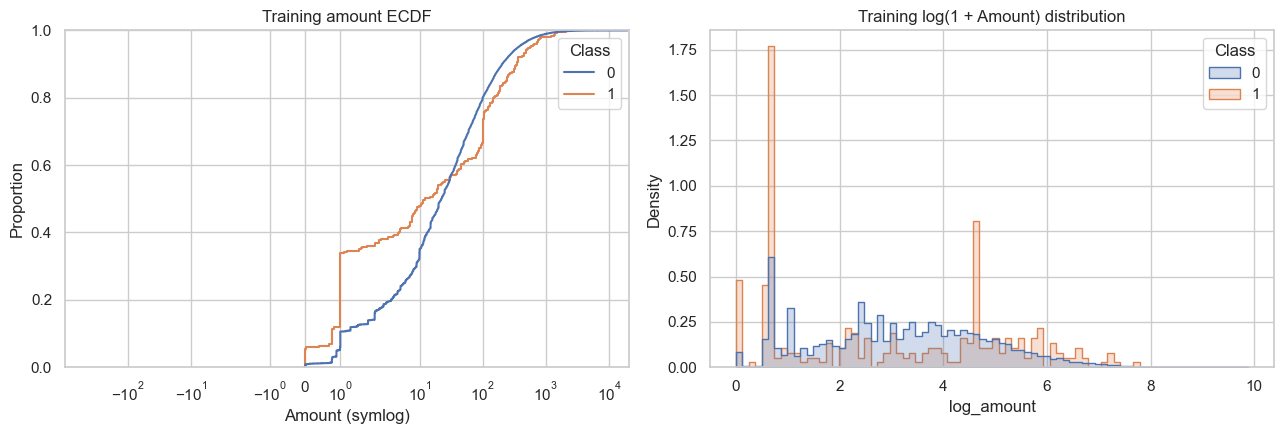

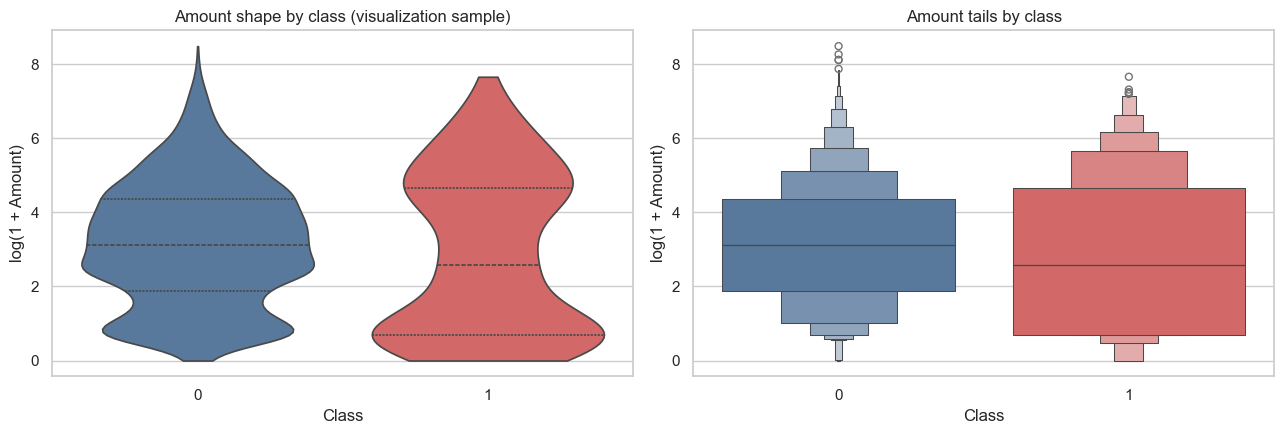

In [7]:
train_eda = X_train.copy()
train_eda["Class"] = y_train

amount_summary = train_eda.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)
display(amount_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.ecdfplot(data=train_eda, x="Amount", hue="Class", ax=axes[0])
axes[0].set(xscale="symlog", title="Training amount ECDF", xlabel="Amount (symlog)")
sns.histplot(
    data=train_eda.assign(log_amount=np.log1p(train_eda["Amount"])),
    x="log_amount",
    hue="Class",
    bins=80,
    stat="density",
    common_norm=False,
    element="step",
    ax=axes[1],
)
axes[1].set(title="Training log(1 + Amount) distribution")
fig.tight_layout()
plt.show()

# A class-balanced visualization sample keeps the fraud shape visible without
# changing any model input or evaluation prevalence.
amount_plot_frame = pd.concat([
    train_eda.loc[train_eda["Class"] == 1],
    train_eda.loc[train_eda["Class"] == 0].sample(
        n=min(5_000, int((train_eda["Class"] == 0).sum())),
        random_state=SEED,
    ),
]).assign(log_amount=lambda frame: np.log1p(frame["Amount"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.violinplot(
    data=amount_plot_frame,
    x="Class",
    y="log_amount",
    inner="quartile",
    cut=0,
    palette=["#4C78A8", "#E45756"],
    hue="Class",
    legend=False,
    ax=axes[0],
)
axes[0].set(title="Amount shape by class (visualization sample)", ylabel="log(1 + Amount)")
sns.boxenplot(
    data=amount_plot_frame,
    x="Class",
    y="log_amount",
    palette=["#4C78A8", "#E45756"],
    hue="Class",
    legend=False,
    ax=axes[1],
)
axes[1].set(title="Amount tails by class", ylabel="log(1 + Amount)")
fig.tight_layout()
plt.show()



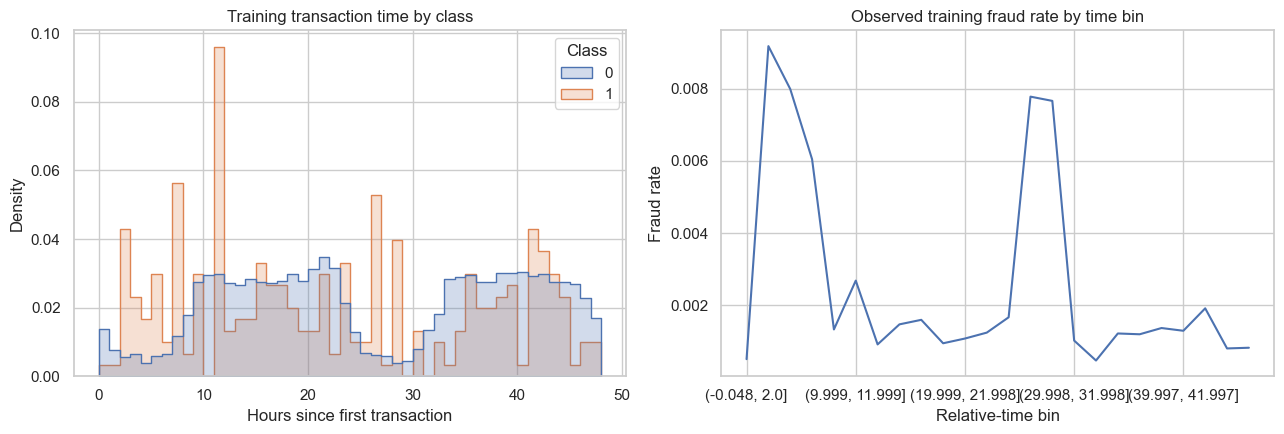

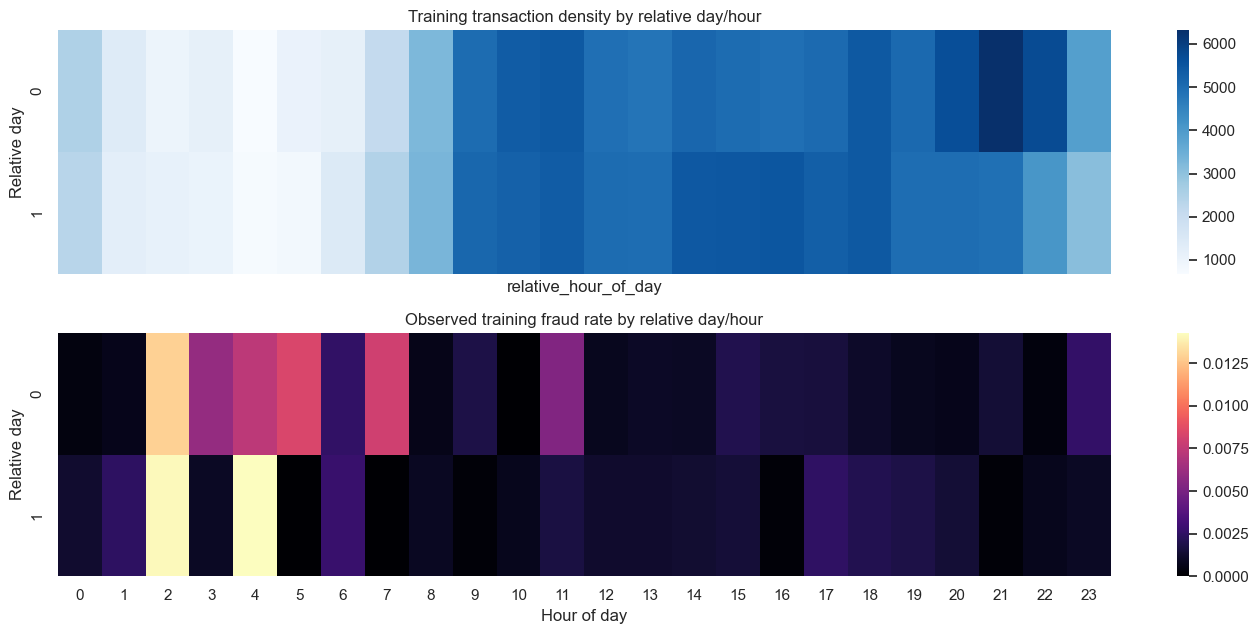

,ANOVA F-score
V17,"20,398.45527"
V14,"18,123.30591"
V12,"12,340.91399"
V10,"8,234.15040"
V3,"6,678.96740"
V16,"6,569.74524"
V7,"5,812.77511"
V11,"4,322.31807"
V4,"3,006.16742"
V18,"2,007.04377"


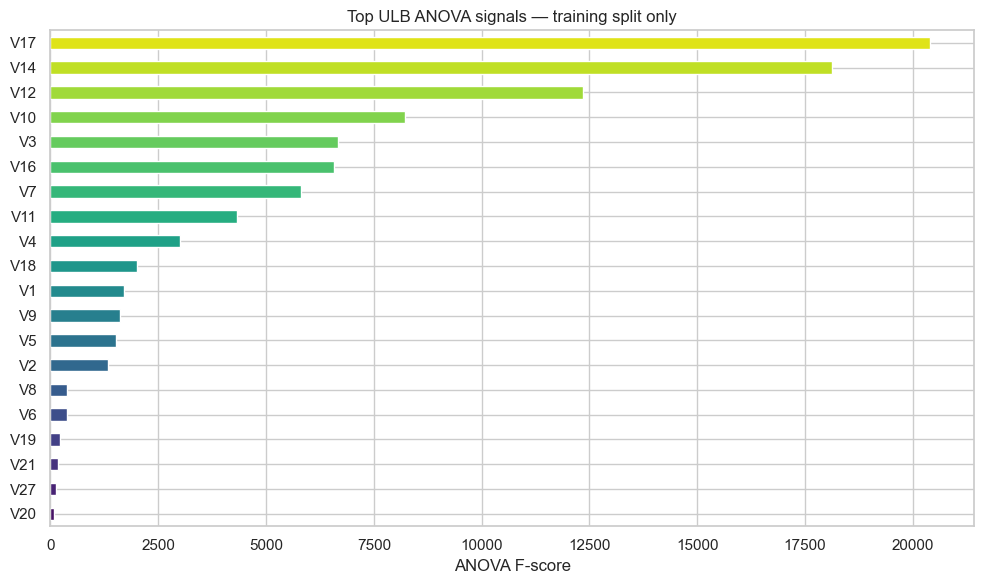

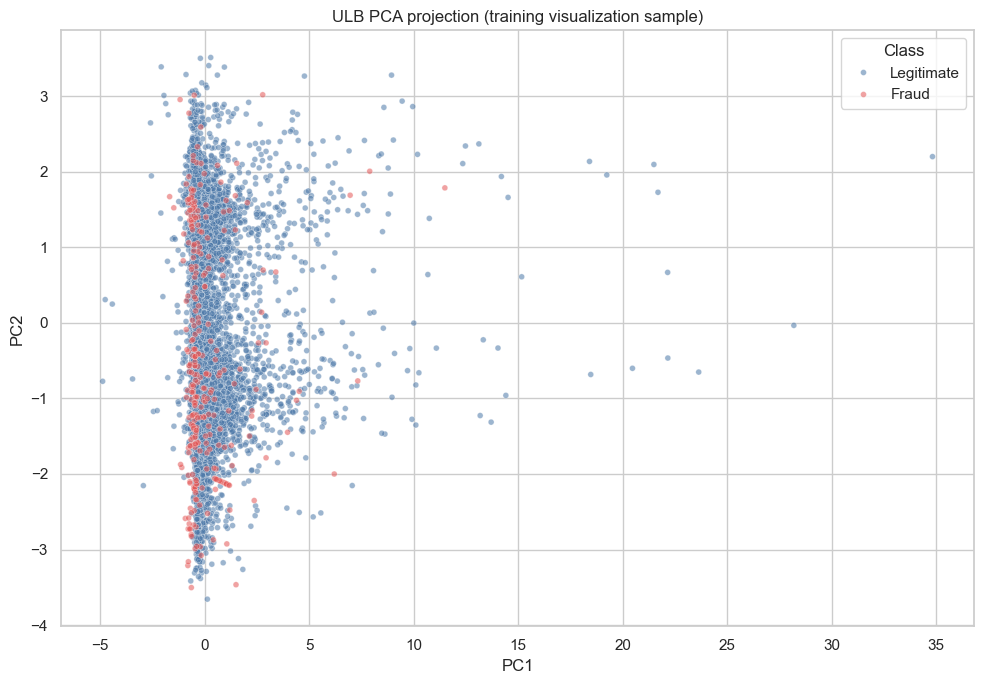

In [8]:
time_eda = train_eda.assign(
    relative_hour=train_eda["Time"] / 3600,
    relative_day=(train_eda["Time"] // 86400).astype(int),
)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(
    data=time_eda,
    x="relative_hour",
    hue="Class",
    bins=48,
    stat="density",
    common_norm=False,
    element="step",
    ax=axes[0],
)
axes[0].set(title="Training transaction time by class", xlabel="Hours since first transaction")
hour_bins = pd.cut(time_eda["relative_hour"], bins=24)
hourly = time_eda.groupby(hour_bins, observed=True)["Class"].agg(["count", "sum", "mean"])
hourly["mean"].plot(ax=axes[1])
axes[1].set(title="Observed training fraud rate by time bin", xlabel="Relative-time bin", ylabel="Fraud rate")
fig.tight_layout()
plt.show()

time_eda["relative_hour_of_day"] = (time_eda["Time"] // 3600).astype(int) % 24
temporal_grid = (
    time_eda.groupby(["relative_day", "relative_hour_of_day"], observed=True)["Class"]
    .agg(transactions="count", fraud="sum", fraud_rate="mean")
    .reset_index()
)
fig, axes = plt.subplots(2, 1, figsize=(14, 6.5), sharex=True)
sns.heatmap(
    temporal_grid.pivot(index="relative_day", columns="relative_hour_of_day", values="transactions"),
    cmap="Blues",
    ax=axes[0],
)
axes[0].set(title="Training transaction density by relative day/hour", ylabel="Relative day")
sns.heatmap(
    temporal_grid.pivot(index="relative_day", columns="relative_hour_of_day", values="fraud_rate"),
    cmap="magma",
    robust=True,
    ax=axes[1],
)
axes[1].set(title="Observed training fraud rate by relative day/hour", xlabel="Hour of day", ylabel="Relative day")
fig.tight_layout()
plt.show()

# This recreates the original notebook's ANOVA ranking without its leakage:
# the score is fitted on the locked training split only and is not used to peek
# at validation or test labels.
anova_scores, _ = f_classif(X_train, y_train)
anova_ranking = (
    pd.Series(anova_scores, index=X_train.columns, name="ANOVA F-score")
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values(ascending=False)
)
display(anova_ranking.head(20).to_frame())

fig, ax = plt.subplots(figsize=(10, 6))
anova_ranking.head(20).sort_values().plot.barh(color=sns.color_palette("viridis", 20), ax=ax)
ax.set(title="Top ULB ANOVA signals — training split only", xlabel="ANOVA F-score")
fig.tight_layout()
plt.show()

# PCA is used only as a two-dimensional visualization of the anonymized feature
# space; it is not the fitted representation used by the predictive models.
pca_legitimate = X_train.loc[y_train == 0].sample(
    n=min(12_000, int((y_train == 0).sum())),
    random_state=SEED,
)
pca_frame = pd.concat([pca_legitimate, X_train.loc[y_train == 1]])
pca_labels = y_train.loc[pca_frame.index]
pca_scaler = StandardScaler().fit(X_train)
pca_model = PCA(n_components=2, random_state=SEED).fit(pca_scaler.transform(X_train))
pca_coordinates = pca_model.transform(pca_scaler.transform(pca_frame))
pca_plot = pd.DataFrame({
    "PC1": pca_coordinates[:, 0],
    "PC2": pca_coordinates[:, 1],
    "Class": pca_labels.map({0: "Legitimate", 1: "Fraud"}).to_numpy(),
})
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_plot,
    x="PC1",
    y="PC2",
    hue="Class",
    hue_order=["Legitimate", "Fraud"],
    palette={"Legitimate": "#4C78A8", "Fraud": "#E45756"},
    alpha=0.55,
    s=18,
)
plt.title("ULB PCA projection (training visualization sample)")
plt.tight_layout()
plt.show()



,legitimate_median,fraud_median,absolute_median_difference
V14,0.05080,-6.66648,6.71729
V12,0.13985,-5.41133,5.55117
V17,-0.06608,-5.36291,5.29683
V3,0.18238,-4.81217,4.99455
V10,-0.09187,-4.50761,4.41574
V4,-0.02434,3.98717,4.01151
V11,-0.03383,3.58622,3.62005
V16,0.06776,-3.34403,3.41179
V7,0.04197,-2.83435,2.87632
V2,0.06199,2.62573,2.56375


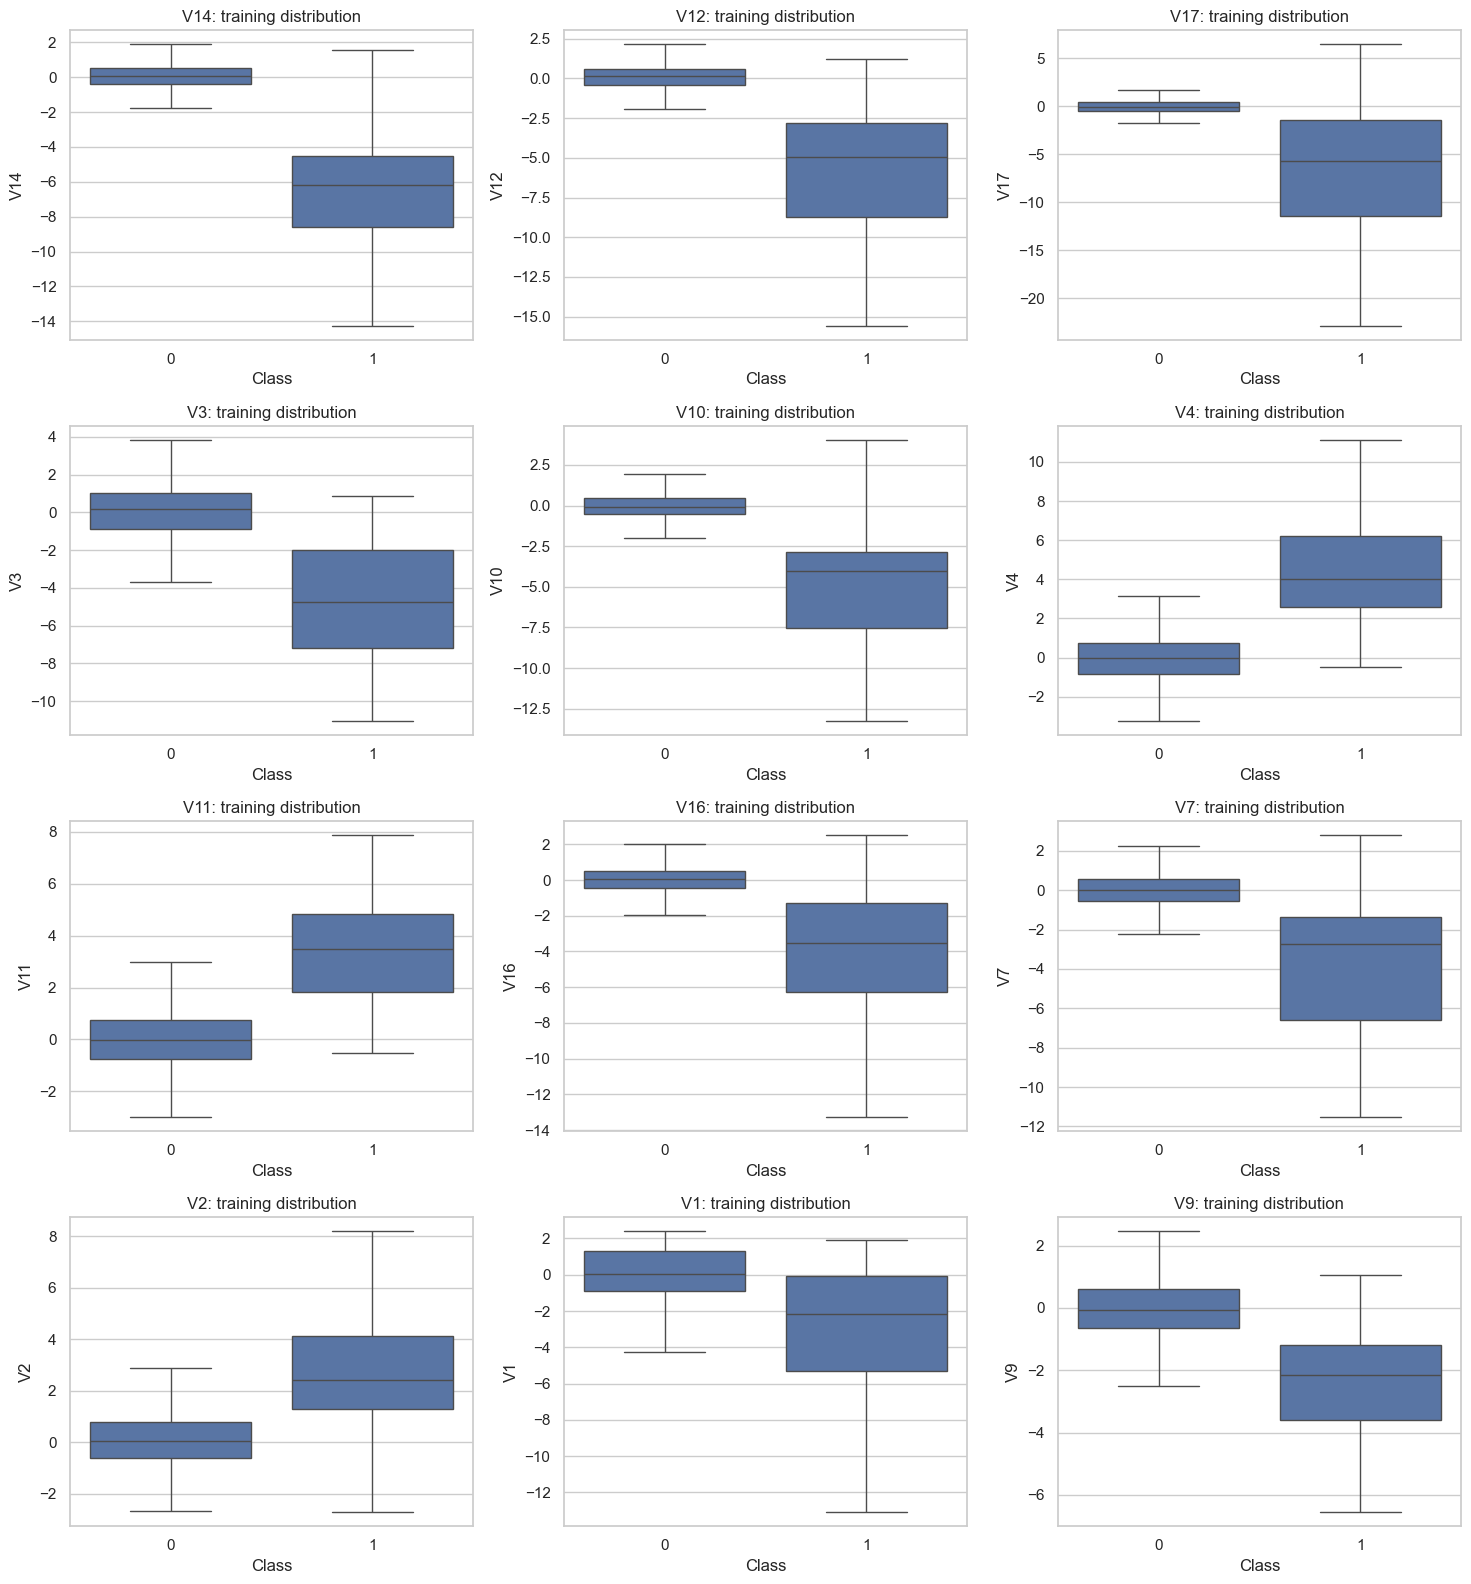

In [9]:
v_columns = [f"V{i}" for i in range(1, 29)]
feature_summary = train_eda.groupby("Class")[v_columns].median().T
feature_summary.columns = ["legitimate_median", "fraud_median"]
feature_summary["absolute_median_difference"] = (
    feature_summary["fraud_median"] - feature_summary["legitimate_median"]
).abs()
feature_summary = feature_summary.sort_values("absolute_median_difference", ascending=False)
display(feature_summary.head(15))

top_features = feature_summary.head(12).index.tolist()
plot_frame = train_eda.sample(min(50_000, len(train_eda)), random_state=SEED)
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
for feature, axis in zip(top_features, axes.flat):
    sns.boxplot(
        data=plot_frame,
        x="Class",
        y=feature,
        showfliers=False,
        ax=axis,
    )
    axis.set_title(f"{feature}: training distribution")
fig.tight_layout()
plt.show()



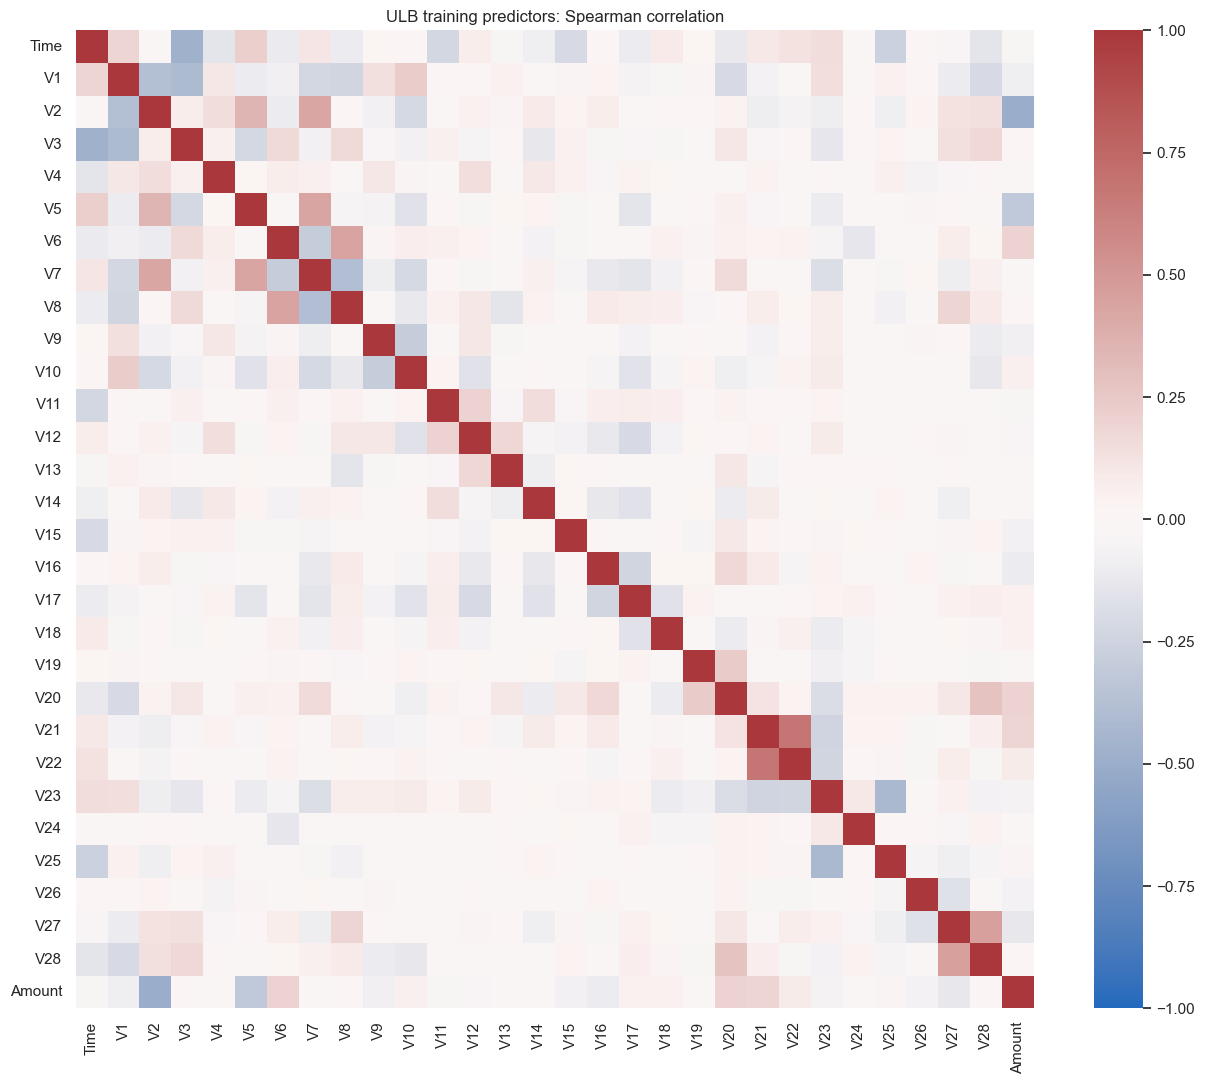

In [10]:
training_correlations = train_eda.drop(columns="Class").corr(method="spearman")
plt.figure(figsize=(13, 11))
sns.heatmap(training_correlations, cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("ULB training predictors: Spearman correlation")
plt.tight_layout()
plt.show()



## 5. Training-only class-balancing experiment

The original notebook combined random under-sampling and SMOTE. Here that idea is
retained as a controlled candidate pipeline, but samplers see **training rows only**.
Validation and test retain their natural fraud prevalence. Scaling precedes SMOTE so
neighbour distances are not dominated by large-scale `Time` or `Amount` values.



,Original training,Under-sampling + SMOTE
Class,,
Legitimate,181282,3020
Fraud,302,1510


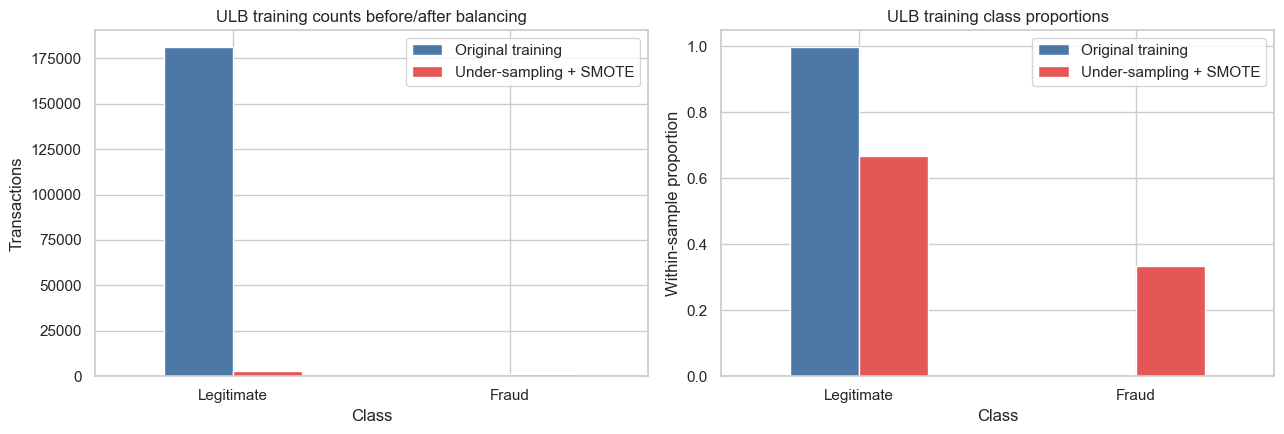

In [11]:
balance_preview = ImbalancedPipeline([
    ("under", RandomUnderSampler(sampling_strategy=0.10, random_state=SEED)),
    ("smote", SMOTE(sampling_strategy=0.50, random_state=SEED, k_neighbors=5)),
])
_, y_train_hybrid_preview = balance_preview.fit_resample(X_train, y_train)

balance_counts = pd.DataFrame({
    "Original training": y_train.value_counts().sort_index(),
    "Under-sampling + SMOTE": pd.Series(y_train_hybrid_preview).value_counts().sort_index(),
}).rename(index={0: "Legitimate", 1: "Fraud"})
display(balance_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
balance_counts.plot.bar(ax=axes[0], color=["#4C78A8", "#E45756"])
axes[0].set(title="ULB training counts before/after balancing", ylabel="Transactions")
(balance_counts / balance_counts.sum()).plot.bar(ax=axes[1], color=["#4C78A8", "#E45756"])
axes[1].set(title="ULB training class proportions", ylabel="Within-sample proportion")
for axis in axes:
    axis.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()



## 6. Candidate models

Weighted baselines and a leakage-safe hybrid-resampling ablation use all predictors.
No sampler is ever applied to validation or test data.



In [12]:
numeric_columns = X_train.columns.tolist()

models = {
    "Dummy prior": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyClassifier(strategy="prior")),
    ]),
    "Logistic regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2_000,
            random_state=SEED,
        )),
    ]),
    "Logistic + hybrid resampling": ImbalancedPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("under", RandomUnderSampler(sampling_strategy=0.10, random_state=SEED)),
        ("smote", SMOTE(sampling_strategy=0.50, random_state=SEED, k_neighbors=5)),
        ("model", LogisticRegression(
            max_iter=2_000,
            random_state=SEED,
        )),
    ]),
    "Random forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced_subsample",
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=SEED,
        )),
    ]),
    "Histogram gradient boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingClassifier(
            class_weight="balanced",
            learning_rate=0.08,
            max_iter=250,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=SEED,
        )),
    ]),
}



## 7. Validation-only model and threshold selection



Training Dummy prior...


Training Logistic regression...


Training Logistic + hybrid resampling...


Training Random forest...


Training Histogram gradient boosting...


,dataset,model,split,threshold_rule,n,fraud_n,fraud_rate,threshold,average_precision,roc_auc,precision,recall,specificity,f1,f2,balanced_accuracy,mcc,brier,tn,fp,fn,tp
6,ULB,Random forest,validation,default_0.5,45396,76,0.00167,0.50000,0.87898,0.95772,0.95522,0.84211,0.99993,0.89510,0.86253,0.92102,0.89672,0.00033,45317,3,12,64
7,ULB,Random forest,validation,validation_tuned,45396,76,0.00167,0.16982,0.87898,0.95772,0.88000,0.86842,0.99980,0.87417,0.87071,0.93411,0.87398,0.00033,45311,9,10,66
4,ULB,Logistic + hybrid resampling,validation,default_0.5,45396,76,0.00167,0.50000,0.82655,0.97177,0.08513,0.88158,0.98411,0.15527,0.30706,0.93285,0.27115,0.01430,44600,720,9,67
5,ULB,Logistic + hybrid resampling,validation,validation_tuned,45396,76,0.00167,0.99970,0.82655,0.97177,0.82278,0.85526,0.99969,0.83871,0.84856,0.92748,0.83859,0.01430,45306,14,11,65
8,ULB,Histogram gradient boosting,validation,default_0.5,45396,76,0.00167,0.50000,0.81996,0.96375,0.43709,0.86842,0.99812,0.58150,0.72527,0.93327,0.61528,0.00217,45235,85,10,66
9,ULB,Histogram gradient boosting,validation,validation_tuned,45396,76,0.00167,0.88113,0.81996,0.96375,0.89041,0.85526,0.99982,0.87248,0.86207,0.92754,0.87245,0.00217,45312,8,11,65
2,ULB,Logistic regression,validation,default_0.5,45396,76,0.00167,0.50000,0.81388,0.97491,0.05423,0.89474,0.97383,0.10226,0.21823,0.93428,0.21666,0.02294,44134,1186,8,68
3,ULB,Logistic regression,validation,validation_tuned,45396,76,0.00167,0.99999,0.81388,0.97491,0.88889,0.84211,0.99982,0.86486,0.85106,0.92096,0.86496,0.02294,45312,8,12,64
0,ULB,Dummy prior,validation,default_0.5,45396,76,0.00167,0.50000,0.00167,0.50000,0.00000,0.00000,1.00000,0.00000,0.00000,0.50000,0.00000,0.00167,45320,0,76,0
1,ULB,Dummy prior,validation,validation_tuned,45396,76,0.00167,0.00166,0.00167,0.50000,0.00167,1.00000,0.00000,0.00334,0.00832,0.50000,0.00000,0.00167,0,45320,0,76


Selected model: Random forest
Validation-selected F2 threshold: 0.16981675118042264


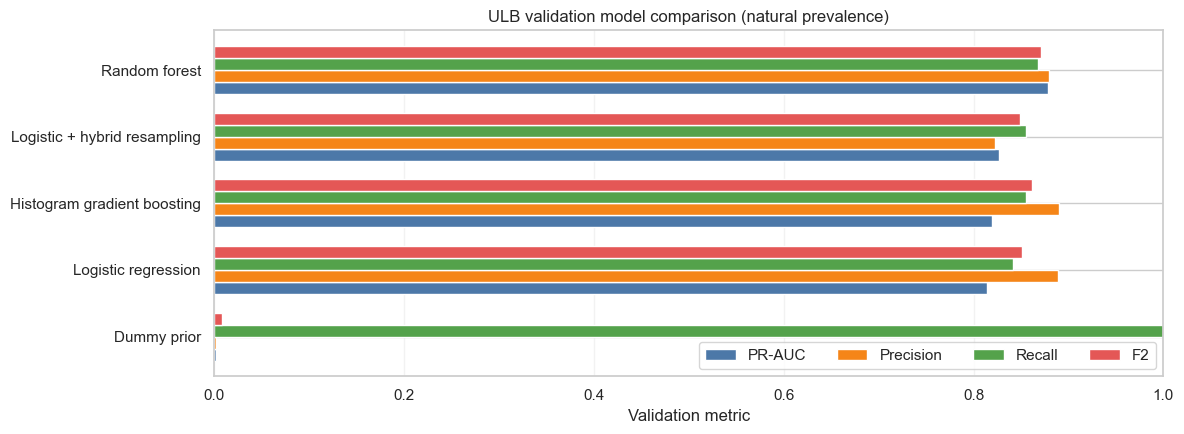

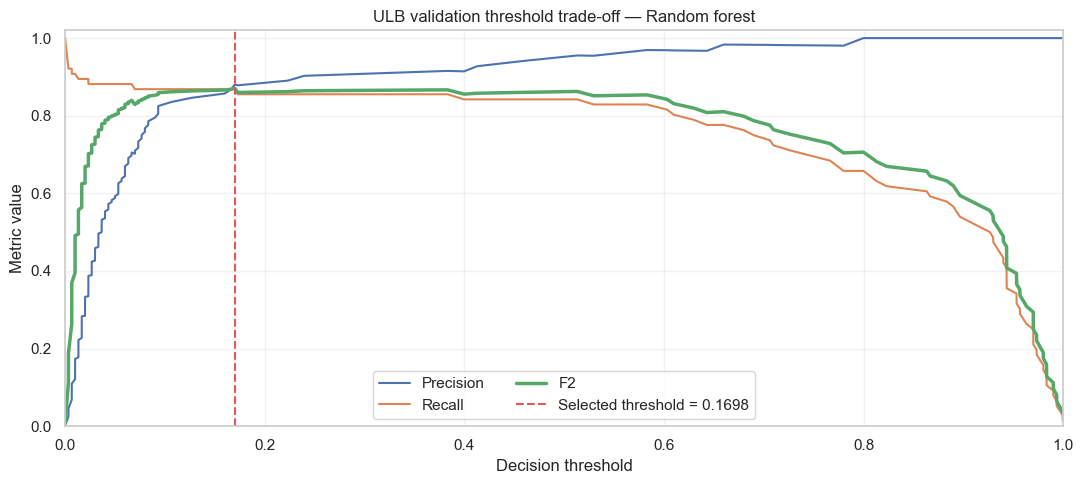

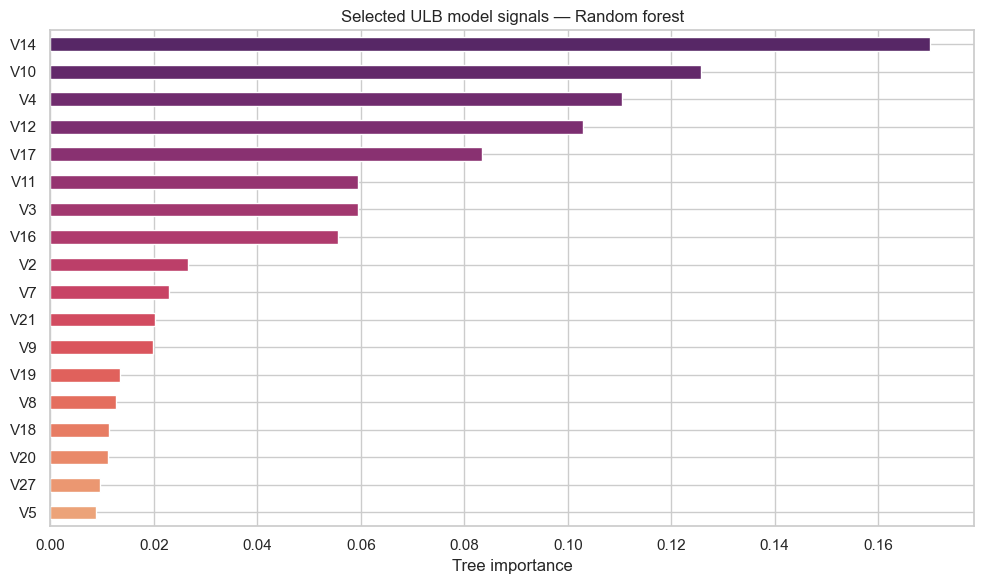

In [13]:
trained_models = {}
validation_rows = []
thresholds = {}
validation_scores = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    trained_models[model_name] = model

    validation_score = positive_class_scores(model, X_validation)
    validation_scores[model_name] = validation_score
    threshold_result = select_fbeta_threshold(
        y_validation,
        validation_score,
        beta=FBETA,
    )
    thresholds[model_name] = threshold_result["threshold"]
    validation_rows.append(
        evaluation_rows(
            dataset="ULB",
            model_name=model_name,
            split="validation",
            y_true=y_validation,
            y_score=validation_score,
            tuned_threshold=threshold_result["threshold"],
            beta=FBETA,
        )
    )

validation_results = pd.concat(validation_rows, ignore_index=True)
display(validation_results.sort_values([PRIMARY_METRIC, "model"], ascending=[False, True]))

selection_table = validation_results[
    validation_results["threshold_rule"] == "validation_tuned"
].sort_values(PRIMARY_METRIC, ascending=False)
best_model_name = selection_table.iloc[0]["model"]
best_model = trained_models[best_model_name]
best_threshold = thresholds[best_model_name]

print("Selected model:", best_model_name)
print("Validation-selected F2 threshold:", best_threshold)

plot_validation_comparison(
    validation_results,
    beta=FBETA,
    title="ULB validation model comparison (natural prevalence)",
)
plt.show()

plot_threshold_tradeoff(
    y_validation,
    validation_scores[best_model_name],
    selected_threshold=best_threshold,
    beta=FBETA,
    title=f"ULB validation threshold trade-off — {best_model_name}",
)
plt.show()

selected_model_step = best_model.named_steps["model"]
if hasattr(selected_model_step, "feature_importances_"):
    importance_values = selected_model_step.feature_importances_
    importance_label = "Tree importance"
elif hasattr(selected_model_step, "coef_"):
    importance_values = np.abs(selected_model_step.coef_[0])
    importance_label = "Absolute standardized coefficient"
else:
    importance_values = None

if importance_values is not None:
    selected_importance = pd.Series(importance_values, index=X_train.columns).nlargest(18)
    fig, ax = plt.subplots(figsize=(10, 6))
    selected_importance.sort_values().plot.barh(
        color=sns.color_palette("flare", len(selected_importance)),
        ax=ax,
    )
    ax.set(
        title=f"Selected ULB model signals — {best_model_name}",
        xlabel=importance_label,
    )
    fig.tight_layout()
    plt.show()



## 8. One-time untouched test evaluation



,dataset,model,split,threshold_rule,n,fraud_n,fraud_rate,threshold,average_precision,roc_auc,precision,recall,specificity,f1,f2,balanced_accuracy,mcc,brier,tn,fp,fn,tp
0,ULB,Random forest,test,default_0.5,56746,95,0.00167,0.50000,0.81731,0.94788,0.97101,0.70526,0.99996,0.81707,0.74610,0.85261,0.82731,0.00047,56649,2,28,67
1,ULB,Random forest,test,validation_tuned,56746,95,0.00167,0.16982,0.81731,0.94788,0.88372,0.80000,0.99982,0.83978,0.81545,0.89991,0.84057,0.00047,56641,10,19,76


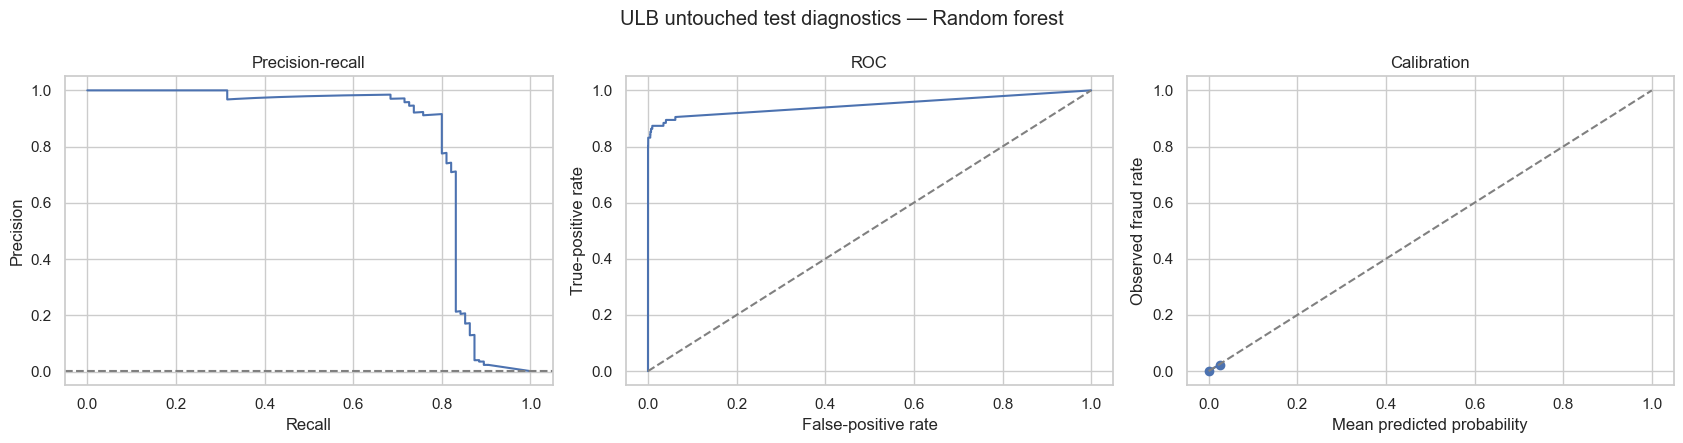

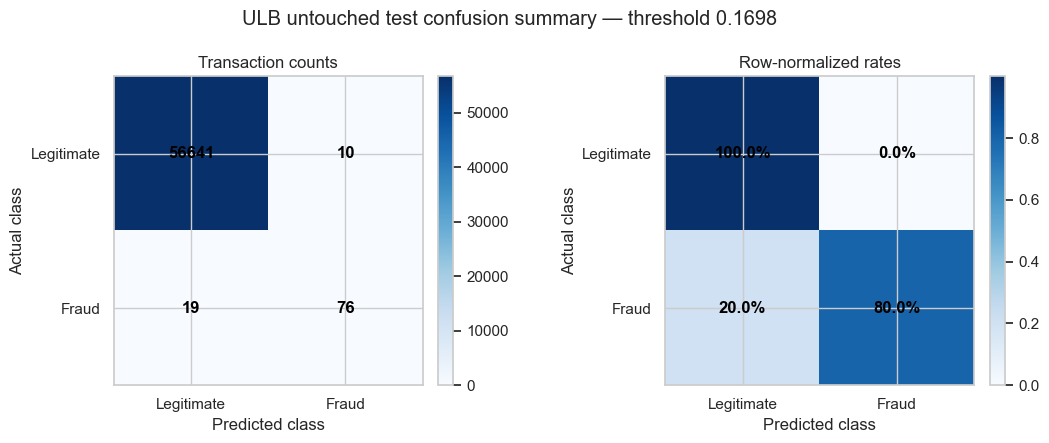

In [14]:
test_score = positive_class_scores(best_model, X_test)
test_results = evaluation_rows(
    dataset="ULB",
    model_name=best_model_name,
    split="test",
    y_true=y_test,
    y_score=test_score,
    tuned_threshold=best_threshold,
    beta=FBETA,
)
display(test_results)

plot_diagnostics(
    y_test,
    test_score,
    title=f"ULB untouched test diagnostics — {best_model_name}",
)
plt.show()

plot_confusion_summary(
    y_test,
    test_score,
    threshold=best_threshold,
    title=f"ULB untouched test confusion summary — threshold {best_threshold:.4f}",
)
plt.show()



## 9. Save reproducible artifacts



In [15]:
joblib.dump(best_model, ARTIFACT_DIR / "selected_pipeline.joblib")
validation_results.to_csv(ARTIFACT_DIR / "validation_metrics.csv", index=False)
test_results.to_csv(ARTIFACT_DIR / "test_metrics.csv", index=False)
pd.DataFrame({
    "row_index": X_test.index,
    "actual": y_test.to_numpy(),
    "fraud_probability": test_score,
}).to_csv(ARTIFACT_DIR / "test_predictions.csv", index=False)

llm_alert_records = build_alert_records(
    dataset_id="ULB",
    features=X_test,
    y_true=y_test,
    scores=test_score,
    threshold=best_threshold,
    model_name=best_model_name,
    record_ids=[f"ulb-test-{index}" for index in X_test.index],
)
write_jsonl(llm_alert_records, ARTIFACT_DIR / "llm_alert_evidence.jsonl")

save_json({
    "dataset": "ULB",
    "data_sha256": data_hash,
    "seed": SEED,
    "duplicate_policy": "retain first row from each exact duplicate group before split",
    "selected_model": best_model_name,
    "primary_metric": PRIMARY_METRIC,
    "threshold_selection": f"maximum validation F{FBETA:g}",
    "selected_threshold": best_threshold,
    "split_manifest": split_manifest.to_dict(orient="records"),
    "versions": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
        "imbalanced_learn": imblearn.__version__,
    },
}, ARTIFACT_DIR / "run_manifest.json")

print("Artifacts saved to", ARTIFACT_DIR)
print("LLM-ready alert records:", len(llm_alert_records))



Artifacts saved to artifacts/ulb
LLM-ready alert records: 86


## 10. Interpretation boundaries

- ULB contains only two days of transactions and 492 labelled frauds before duplicate handling.
- `V1`-`V28` are anonymized components, so domain interpretation is limited.
- Random stratification estimates interpolation within this snapshot, not future deployment drift.
- A time-ordered sensitivity analysis and bootstrap confidence intervals should accompany final thesis tables.
- The test set must not be revisited after results are incorporated into the thesis.
